In [6]:
from src.data.bayesian_b_updater import BayesianGRBUpdater# %%
import src
from src.data.preparation import prepare_data_tpp
from config.config_loader import load_args_from_yaml 

In [7]:
args= load_args_from_yaml("../config/mixer_tpp.yaml")
args.dataset = 'ChuanDian'
base_dir = f"../data/{args.dataset}"
# %%
seq, train_loader, val_loader, test_loader, catalog_ds = prepare_data_tpp(base_dir=base_dir, args=args,)

Using catalog dataset class: <class 'src.catalogs.chuandian.ChuanDianStandard'>
Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/ChuanDian/raw.
Using Bayesian GR b-value updater with delta=0.98, a0=20.0, init b=1.0000, mag_completeness=3.0
Number of training events: 4498
Number of validation events: 567


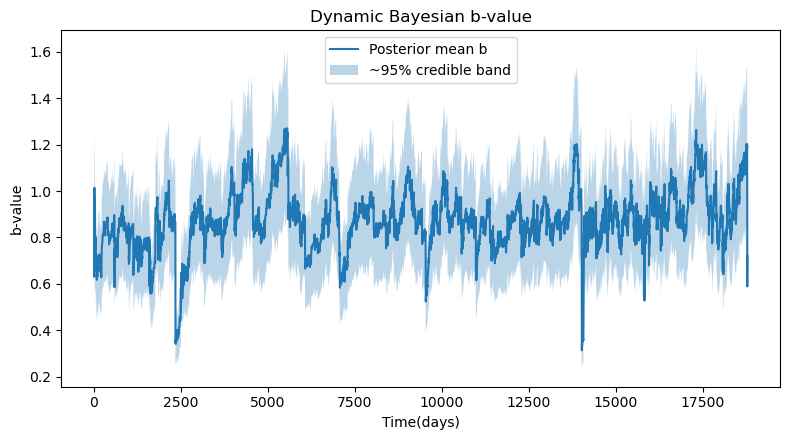

In [9]:
updater = BayesianGRBUpdater(Mc=3, delta=0.98, a0=50, init_b_target=1, mag_key="mag", write_back=True)
results = updater.fit(seq,prefix="bayes_")    
BayesianGRBUpdater.plot(seq, x_axis="time", time_key="arrival_times",prefix="bayes_")          

似然最大取值与Gamma分布期望的差异

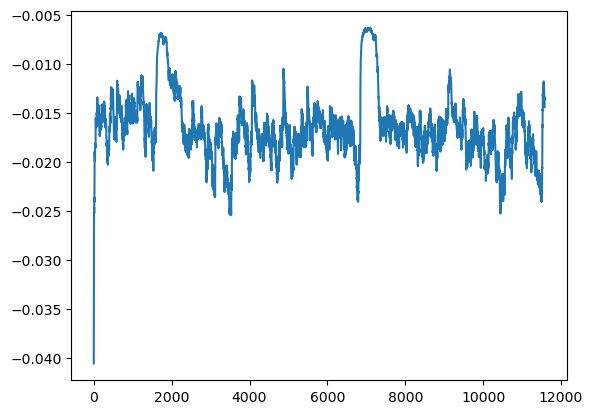

In [10]:
import math
import matplotlib.pyplot as plt
diff = (seq.a_t-1)/(math.log(10)*seq.s_t)-(seq.a_t)/(math.log(10)*seq.s_t)  
# diff.mean()
# diff.max()
plt.plot(diff)

In [11]:
seq

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580],
  a_t: [11580],
  s_t: [11580],
  b_mean: [11580],
  b_sd: [11580],
  b_lo: [11580],
  b_hi: [11580],
  used_mask: [11580],
  bayes_a_t: [11580],
  bayes_s_t: [11580],
  bayes_b_mean: [11580],
  bayes_b_sd: [11580],
  bayes_b_lo: [11580],
  bayes_b_hi: [11580],
  bayes_used_mask: [11580]
)

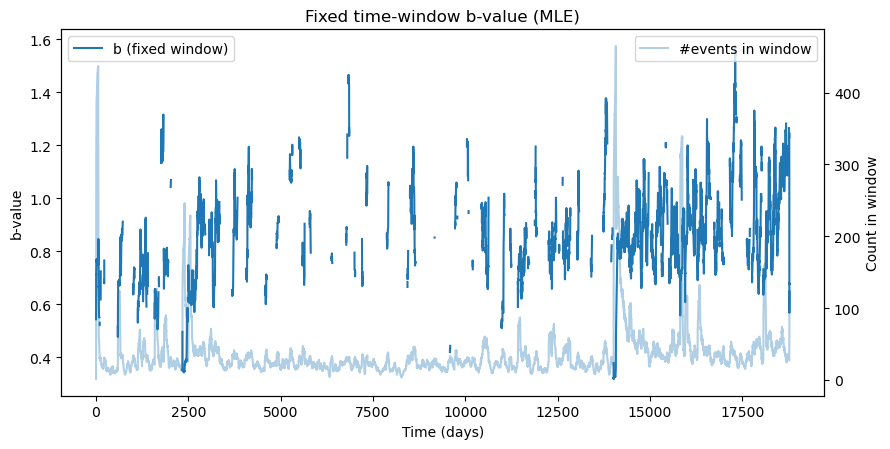

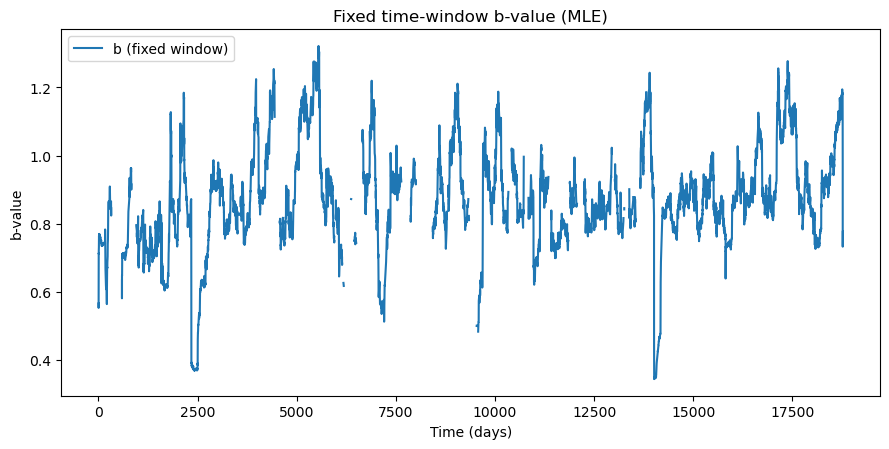

In [12]:
from src.data.slidewindow_b_updater import FixedTimeWindowGRB
est = FixedTimeWindowGRB(Mc=3.0, window_len=60.0, min_count=30,
                         mag_key="mag", time_key="arrival_times",
                         method="mle")   # 或 method="bayes", a0=..., s0=...
est.fit(seq,prefix="fixed_")
FixedTimeWindowGRB.plot(seq, x_axis="time", show_counts=True,prefix="fixed_")

# 方式 B：按目标事件数先估一个“固定窗长”，再全程使用该窗长（例如目标 100 个事件）
est_auto = FixedTimeWindowGRB(Mc=3.0, target_count=100, min_count=50,
                              mag_key="mag", time_key="arrival_times",
                              method="mle")
est_auto.fit(seq,prefix="fixed_")
FixedTimeWindowGRB.plot(seq, x_axis="time", show_counts=False,prefix="fixed_")


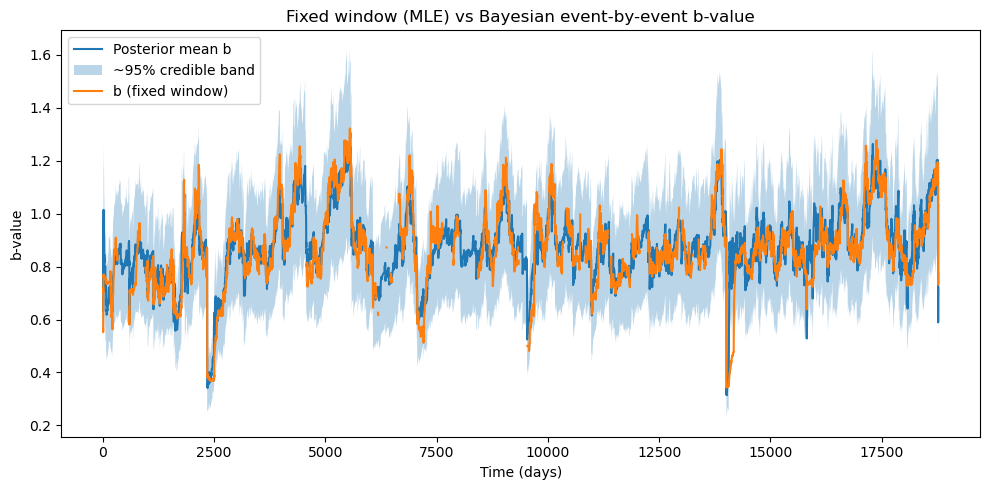

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

BayesianGRBUpdater.plot(seq,
                        x_axis="time",
                        time_key="arrival_times",
                        ax=ax,
                        title="",            # 不覆盖标题
                        prefix="bayes_",
                        show=False)
FixedTimeWindowGRB.plot(seq,
                        x_axis="time",
                        show_counts=False,   # 关闭右侧计数轴，避免遮挡
                        ax=ax,
                        title="",           # 标题最后统一设置
                        prefix="fixed_",
                        show=False)
ax.set_title("Fixed window (MLE) vs Bayesian event-by-event b-value")
ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [16]:
from  src.train.config_setup import load_and_prepare_model
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model("../checkpoints/mixer_tpp_20250912-205124/best_model_1.pth",device="cpu")

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.